In [ ]:
!mkdir -p ~/.kaggle
!cp /kaggle.json ~/.kaggle

In [ ]:
# !kaggle datasets download -d marquis03/cats-and-dogs
!kaggle datasets download -d birajsth/cats-and-dogs-filtered

Dataset URL: https://www.kaggle.com/datasets/birajsth/cats-and-dogs-filtered
License(s): unknown
100% 131M/131M [00:10<00:00, 13.1MB/s]



In [ ]:
import zipfile
# zip_ref = zipfile.ZipFile("/content/cats-and-dogs.zip")
zip_ref = zipfile.ZipFile("/content/cats-and-dogs-filtered.zip")
zip_ref.extractall('/content')
zip_ref.close()

In [ ]:
from keras.applications import vgg16
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Flatten,GlobalAveragePooling2D
from keras.applications.vgg16 import VGG16

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(150,150,3)
)

base_model.summary()

model = Sequential()

model.add(base_model)
model.add(GlobalAveragePooling2D())
# model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))
# model.summary()

base_model.trainable = False

train = keras.utils.image_dataset_from_directory(
    # directory = '/content/train', cat vs dog old dataset
    directory = '/content/cats_and_dogs_filtered/train',
    labels= 'inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(150,150)
)

test = keras.utils.image_dataset_from_directory(
    # directory = '/content/val',
    directory = '/content/cats_and_dogs_filtered/validation',
    labels= 'inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(150,150)
)

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_21 (InputLayer)     │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


In [ ]:
# normalization
def process(image,label):
    image = tensorflow.cast(image/255. ,tensorflow.float32)
    return image,label

train = train.map(process)
test = test.map(process)

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
history = model.fit(train,epochs=10,validation_data=test)


Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 26s 377ms/step - accuracy: 0.7915 - loss: 0.4441 - val_accuracy: 0.8590 - val_loss: 0.3267
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 179ms/step - accuracy: 0.8720 - loss: 0.3114 - val_accuracy: 0.8730 - val_loss: 0.2906
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 172ms/step - accuracy: 0.8905 - loss: 0.2641 - val_accuracy: 0.8720 - val_loss: 0.2881
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 171ms/step - accuracy: 0.9005 - loss: 0.2364 - val_accuracy: 0.8870 - val_loss: 0.2796
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 174ms/step - accuracy: 0.9075 - loss: 0.2208 - val_accuracy: 0.8850 - val_loss: 0.2663
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 175ms/step - accuracy: 0.9185 - loss: 0.2051 - val_accuracy: 0.8660 - val_loss: 0.3221
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 181ms/step - accuracy: 0.9175 - loss: 0.2051 - val_accuracy: 0.8850 - val_loss: 0.2626
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 187ms/step - accuracy: 0.9275 - loss: 0.1854 - val_accu

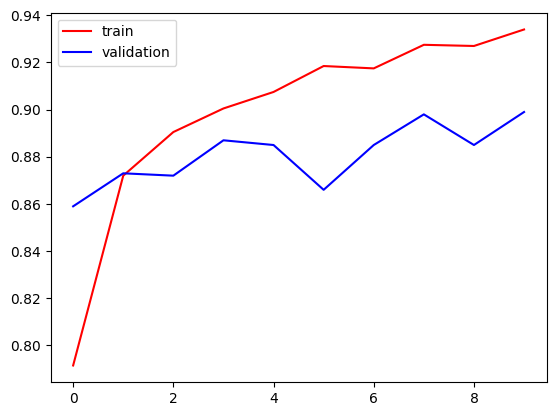

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

Fine tuning

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_23 (InputLayer)     │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 7,079,424 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 254ms/step - accuracy: 0.7455 - loss: 0.5559 - val_accuracy: 0.8330 - val_loss: 0.4063
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 207ms/step - accuracy: 0.8850 - loss: 0.3000 - val_accuracy: 0.8910 - val_loss: 0.2577
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 214ms/step - accuracy: 0.9195 - loss: 0.2104 - val_accuracy: 0.9030 - val_loss: 0.2286
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 202ms/step - accuracy: 0.9395 - loss: 0.1647 - val_accuracy: 0.8950 - val_loss: 0.2506
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 195ms/step - accuracy: 0.9530 - loss: 0.1405 - val_accuracy: 0.9100 - val_loss: 0.2056
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 193ms/step - accuracy: 0.9550 - loss: 0.1194 - val_accuracy: 0.9120 - val_loss: 0.1974
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 194ms/step - accuracy: 0.9720 - loss: 0.0947 - val_accuracy: 0.9160 - val_loss: 0.1923
Epoch 8/10
63/6

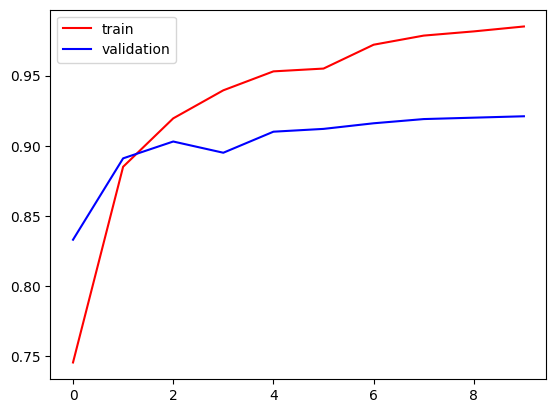

In [ ]:
from keras.applications import vgg16
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.optimizers import Adam
from keras.layers import Dense,Flatten,GlobalAveragePooling2D
from keras.applications.vgg16 import VGG16

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(150,150,3)
)

base_model.trainable = True

set_trainable = False

for layer in base_model.layers:
  if layer.name == 'block5_conv1':
    set_trainable = True
  if set_trainable:
    layer.trainable = True
  else:
    layer.trainable = False

base_model.summary()

model = Sequential()

model.add(base_model)
model.add(GlobalAveragePooling2D())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))
# model.summary()

train = keras.utils.image_dataset_from_directory(
    # directory = '/content/train',
    directory = '/content/cats_and_dogs_filtered/train',
    labels= 'inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(150,150)
)

test = keras.utils.image_dataset_from_directory(
    # directory = '/content/val',
    directory = '/content/cats_and_dogs_filtered/validation',
    labels= 'inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(150,150)
)

# normalization
def process(image,label):
    image = tensorflow.cast(image/255. ,tensorflow.float32)
    return image,label

train = train.map(process)
test = test.map(process)

model.compile(optimizer=Adam(learning_rate=1e-5),loss='binary_crossentropy',metrics=['accuracy'])
history = model.fit(train,epochs=10,validation_data=test)

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()